# Analyse des pathologies et traitements - Assurance Maladie (version Pandas)

# Objectif

Ce notebook présente une analyse statistique des effectifs de patients pris en charge par pathologie et par traitement en France.
L’étude a été réalisée en Python selon deux approches :
- Une version en Python natif (sans bibliothèque spécialisée),
- Une version en Python natif (sans bibliothèque spécialisée),

Cela permet de montrer deux approches différentes pour analyser le même jeu de données.

---

## Plan

1. Chargement et nettoyage
2. Indicateurs globaux
3. Analyse par pathologie
4. Analyse temporelle
5. Analyse territoriale
6. Détection d’anomalies

In [4]:
import sys
from pathlib import Path

# Trouver les fichiers utiles dans les différents dossiers
racine = Path("..")
sys.path.append(str(racine / "core")) # Pour trouver stats_pandas.py
sys.path.append(str(racine)) # Pour trouver conversion.py dans le dossier utils

# Maintenant on peut importer le module
import stats_pandas as sp

# Chargement du dataframe
df = sp.charger_effectifs()

df.head()

,annee,libelle_classe_age,libelle_sexe,dept,Ntop,Npop,prev,pathologie,departement
501,2019,de 0 à 4 ans,hommes,971,290,9680,2.985,Traitements antalgiques ou anti-inflammatoires...,Guadeloupe
502,2019,de 0 à 4 ans,hommes,973,600,11670,5.108,Traitements antalgiques ou anti-inflammatoires...,Guyane
504,2019,de 0 à 4 ans,hommes,75,3640,53490,6.797,Traitements antalgiques ou anti-inflammatoires...,Paris
505,2019,de 0 à 4 ans,hommes,95,3910,46680,8.372,Traitements antalgiques ou anti-inflammatoires...,Val-d'Oise
507,2019,de 0 à 4 ans,hommes,28,810,12010,6.735,Traitements antalgiques ou anti-inflammatoires...,Eure-et-Loir


La fonction def charger_effectifs() remplit plusieurs rôles distincts.

### Importation du fichier Parquet

Le jeu de données initial était au format CSV, mais il a été converti en .parquet afin de réduire la taille du fichier et d’accélérer le traitement. La bibliothèque Pandas permet de lire ce fichier Parquet de la même manière qu’un CSV classique.

### Nettoyage des données

Certaines données sont agrégées ou non exploitables et peuvent fausser les statistiques.
C’est le cas notamment pour :

- les pathologies intitulées `Total consommants tous régimes` ;

- les lignes dont le champ `top` vaut `POP_TOT_IND` ;

- le département `999`, qui représente la France entière.

Ces lignes sont filtrées afin de ne conserver que les données exploitables pour les analyses statistiques, et cela grâce à ce bloc :

```
df = df[~(df["patho_niv1"].str.contains("Total consommants tous régimes", na=False) |
df["patho_niv2"].str.contains("Total consommants tous régimes", na=False) | 
df["patho_niv3"].str.contains("Total consommants tous régimes", na=False))]

df = df[df["top"] != "POP_TOT_IND"]
df = df[df["dept"] != "999"]
```

### Création de la colonne pathologie

Pour chaque enregistrement, la fonction crée une colonne pathologie correspondant au niveau le plus précis disponible parmi les trois niveaux de pathologies (patho_niv3, patho_niv2, patho_niv1).

Le fonctionnement est le suivant :

- On prend d’abord patho_niv3 si elle est renseignée.

- Si patho_niv3 est vide, on utilise patho_niv2.

- Si patho_niv2 est également vide, on prend patho_niv1.

Cette approche garantit que chaque ligne possède un nom de pathologie exploitable, en privilégiant le niveau de détail le plus fin possible.

In [7]:
# Test rapide du Dataset à l'aide des premières fonctions 

print("Nombre de lignes :", sp.nombre_de_lignes(df))
print("Nombre de pathologies :", sp.pathologies_distinctes(df))
print("Nombre de départements :", sp.departements_distincts(df))
print("Nombre d'années :", sp.annees_distinctes(df))
print("Nombre total de cas :", sp.nombre_de_cas(df))
print("Population totale :", sp.population_reference(df))
print("Prévalence globale (%) :", sp.prevalence_globale(df))
print("Prévalence moyenne (%) :", sp.prevalence_moyenne(df))

Nombre de lignes : 3113984
Nombre de pathologies : 78
Nombre de départements : 101
Nombre d'années : 9
Nombre total de cas : 4705812520
Population totale : 155763537350
Prévalence globale (%) : 3.021
Prévalence moyenne (%) : 4.636


### Différence entre prévalence globale et prévalence moyenne

- **Prévalence globale** :  
  Elle est calculée sur l'ensemble des données en tenant compte de la population de chaque groupe.  
  Formule :   (total des cas / population totale) * 100
  Elle reflète la proportion réelle de cas dans la population étudiée.

- **Prévalence moyenne** :  
  C'est la moyenne arithmétique des prévalences calculées pour chaque sous-groupe (ex. par département, sexe ou tranche d'âge), **sans pondération par la taille des populations**.  
  Formule :  prevalence de chaque ligne étudiée / nombre de ligne(s) étudiée(s)
  Elle permet d’observer la tendance moyenne entre les sous-groupes, mais **ne reflète pas la prévalence réelle dans l’ensemble de la population**.

In [12]:
# Test de l'une des fonctions principales stats_patho

"""
Nous allons choisir une pathologie (obligatoire), mais pouvons aussi 
choisir en plus un sexe, une tranche d'âge, un département ou une année 
pour avoir les statistiques filtrées
"""

patho = "Diabète"

print(sp.stats_patho(df, patho))

Ntop_totale            141,626,040.000
Npop_totale          2,333,284,270.000
prevalence_globale               6.070
prevalence_moyenne               8.292
prevalence_mediane               5.662
prevalence_min                   0.018
prevalence_max                  39.822
ecart_type                       8.223
dtype: float64


In [15]:
# Test de la même fonction avec un filtrage sur le sexe
print(sp.stats_patho(df, patho, sexe="hommes"))

Ntop_totale           38,812,160.000
Npop_totale          556,054,900.000
prevalence_globale             6.980
prevalence_moyenne             9.744
prevalence_mediane             6.909
prevalence_min                 0.021
prevalence_max                36.361
ecart_type                     9.312
dtype: float64


In [17]:
"""
Maintenant on analyse la pathologie / traitement par sexe (ici pour le diabète).
Notre fonction stats_par_sexe retourne un dataframe groupant les stats pour 
les femmes et hommes (en index)
"""

print(sp.stats_par_sexe(df, patho))

        Ntop_totale  Npop_totale  prevalence_globale  prevalence_moyenne  \
sexe                                                                       
femmes     32000900    604065440               5.298               7.114   
hommes     38812160    556054900               6.980               9.744   

        prevalence_mediane  prevalence_min  prevalence_max  ecart_type  
sexe                                                                    
femmes               4.935           0.020          39.822       7.046  
hommes               6.909           0.021          36.361       9.312  


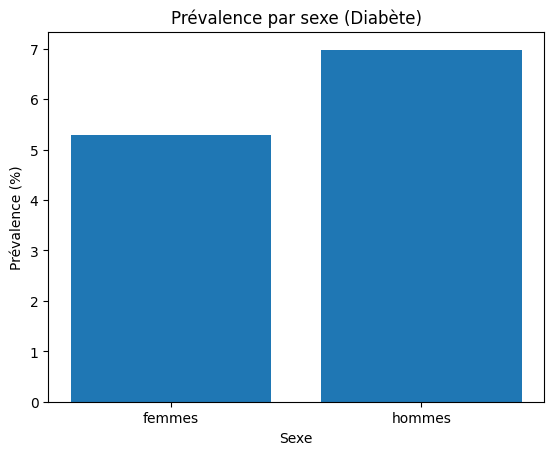

In [22]:
"""
Cela nous permet de faire un graphique comparatif, que l'on peut voir sur 
le Dashboard streamlit. On utilisera matplotlib pour l'affichage de graphique.
"""

import matplotlib.pyplot as plt

df_sexe = sp.stats_par_sexe(df, pathologie)

plt.figure()
plt.bar(df_sexe.index, df_sexe["prevalence_globale"])
plt.title(f"Prévalence par sexe ({pathologie})")
plt.xlabel("Sexe")
plt.ylabel("Prévalence (%)")
plt.show()

In [24]:
# Test des fonctions ratio_cas_hf et difference_prevalence_sexe

print("Ratio des cas H/F : ", sp.ratio_cas_hf(df, patho))
print("Différence de prévalence hommes - femmes : ", sp.difference_prevalence_sexe(df, patho))

Ratio des cas H/F :  1.213
Différence de prévalence hommes - femmes :  1.682
